In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load and Display Image

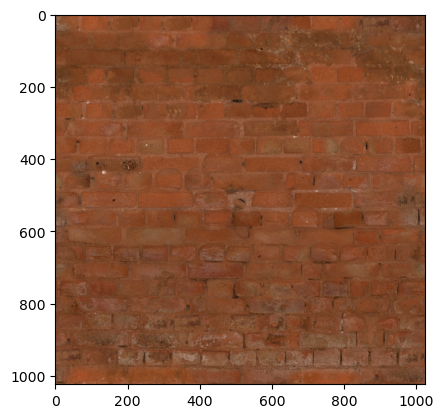

In [2]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

image = Image.open(material_textures_path + "albedo" + ext).convert("RGB").resize((1024, 1024))
image_array = np.asarray(image, dtype=np.float32) * (1/255.00)

fig, ax = plt.subplots()
ax.imshow(image_array)

plt.show()

# Block Struct

In [3]:
block_size = 4
num_interp_values = 4
interp_values = np.zeros(num_interp_values)

for i in range(num_interp_values):
    interp_values[i] = (i * 1.0) / (num_interp_values - 1.0)

class Block:
    def __init__(self):
        self.min_endpoint = np.ones((3), dtype=np.float32)
        self.max_endpoint = np.zeros((3), dtype=np.float32)
        
        self.indices = np.zeros((block_size, block_size, 1), dtype=np.uint8)

    def get_color_at_index(self, index):
        interp_value = interp_values[index]
        interp_color = (1.0 - interp_value) * self.min_endpoint + interp_value * self.max_endpoint

        return interp_color

    def get_color_at_coord(self, x, y):
        interp_index = self.indices[y][x]
        interp_color = self.get_color_at_index(interp_index)

        return interp_color

# Generate Block Image for Reference

In [8]:
block_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

x_offset = 100
y_offset = 440

max_x_offset = image_array.shape[0] - block_size
max_y_offset = image_array.shape[1] - block_size

x_offset = max(0, min(max_x_offset, x_offset))
y_offset = max(0, min(max_y_offset, y_offset))

for x in range(block_size):
    for y in range(block_size):
        block_array[y][x] = image_array[y+y_offset][x+x_offset]

# Compress Block

In [21]:
test_block = Block()

for x in range(block_size):
    for y in range(block_size):
        color = block_array[y][x]

        test_block.min_endpoint = np.minimum(color, test_block.min_endpoint)
        test_block.max_endpoint = np.maximum(color, test_block.max_endpoint)

for x in range(block_size):
    for y in range(block_size):
        shortest_distance = 100.0
        closest_index = 0

        original_color = block_array[y][x]

        for i in range(interp_values.shape[0]):
            interp_value = interp_values[i]
            interp_color = (1.0 - interp_value) * test_block.min_endpoint + interp_value * test_block.max_endpoint

            distance = abs(np.linalg.norm(interp_color - original_color))
            
            if distance < shortest_distance:
                closest_index = i
                shortest_distance = distance

        test_block.indices[y][x] = closest_index

In [22]:
decompressed_block_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

for x in range(block_size):
    for y in range(block_size):
        decompressed_block_array[y][x] = test_block.get_color_at_coord(x, y)

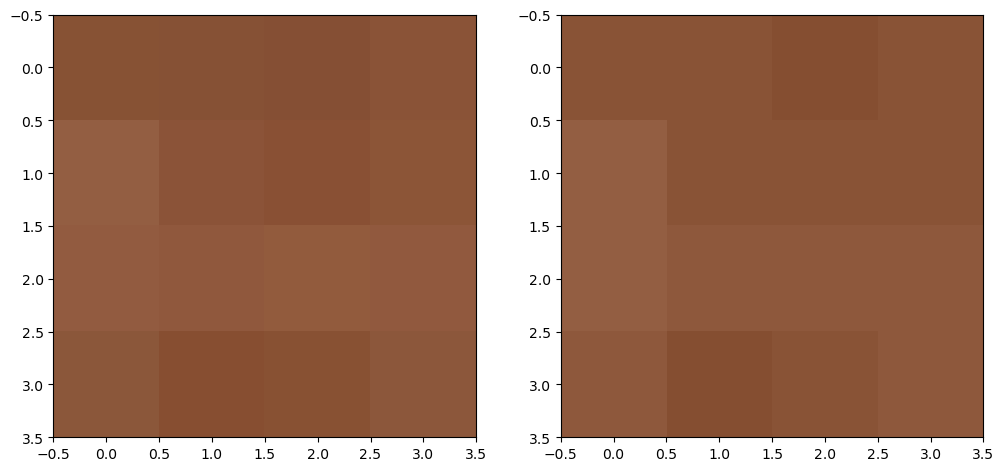

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(block_array)
axes[1].imshow(decompressed_block_array)

plt.show()

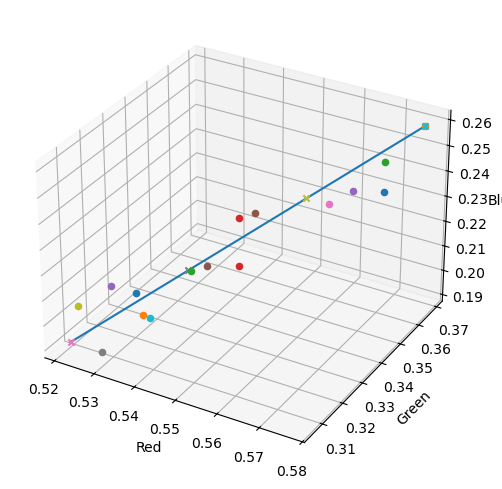

In [24]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(projection='3d')
ax.set_ybound(lower=0.0, upper=1.0)
ax.set_xbound(lower=0.0, upper=1.0)
ax.set_zbound(lower=0.0, upper=1.0)

for x in range(block_size):
    for y in range(block_size):
        ax.scatter(block_array[y][x][0], block_array[y][x][1], block_array[y][x][2])

for i in range(num_interp_values):
    interp_color = test_block.get_color_at_index(i)

    ax.scatter(interp_color[0], interp_color[1], interp_color[2], marker='x')

x_points = [test_block.min_endpoint[0], test_block.max_endpoint[0]]
y_points = [test_block.min_endpoint[1], test_block.max_endpoint[1]]
z_points = [test_block.min_endpoint[2], test_block.max_endpoint[2]]

ax.plot(x_points, y_points, z_points)

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

plt.show()